# 08 — Final Evaluation

End-to-end pipeline summary: pose estimation → rep counting → form classification → quality scoring.

Consolidates results from all previous notebooks into summary figures and tables for the final report.

In [1]:
import sys
sys.path.insert(0, "..")

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import torch
from pathlib import Path

RESULTS_DIR = Path("../outputs/results")
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Loading results from previous notebooks...")

# Notebook 03: Benchmark results
bench_path = RESULTS_DIR / "full_benchmark.csv"
if bench_path.exists():
    df_bench = pd.read_csv(bench_path) if (RESULTS_DIR / "full_benchmark.csv").exists() else None
else:
    df_bench = pd.read_csv("../data/processed/benchmark/full_benchmark.csv") if Path("../data/processed/benchmark/full_benchmark.csv").exists() else None

# Notebook 05: Rep counting
df_counting = pd.read_csv(RESULTS_DIR / "rep_counting_baseline.csv") if (RESULTS_DIR / "rep_counting_baseline.csv").exists() else None

# Notebook 06: Classification
df_classification = pd.read_csv(RESULTS_DIR / "form_classification_results.csv") if (RESULTS_DIR / "form_classification_results.csv").exists() else None
df_class_summary = pd.read_csv(RESULTS_DIR / "form_classification_summary.csv") if (RESULTS_DIR / "form_classification_summary.csv").exists() else None

# Notebook 07: Quality
df_quality = pd.read_csv(RESULTS_DIR / "quality_scores.csv") if (RESULTS_DIR / "quality_scores.csv").exists() else None

loaded = {
    "Benchmark": df_bench is not None,
    "Rep counting": df_counting is not None,
    "Classification": df_classification is not None,
    "Quality scores": df_quality is not None,
}
for name, ok in loaded.items():
    print(f"  {name}: {'loaded' if ok else 'NOT FOUND'}")

Loading results from previous notebooks...
  Benchmark: loaded
  Rep counting: loaded
  Classification: loaded
  Quality scores: loaded


## Section 1: Pipeline Overview

Visual summary of the end-to-end pipeline with key numbers at each stage.

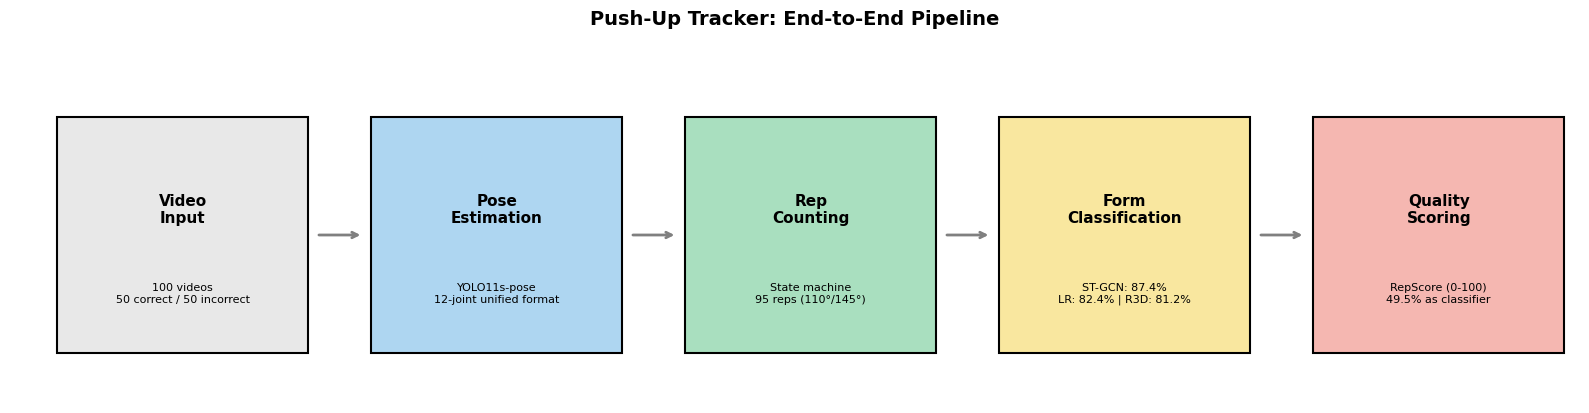

In [2]:
# Pipeline overview figure
fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2)
ax.axis("off")

# Pipeline stages
stages = [
    ("Video\nInput", "100 videos\n50 correct / 50 incorrect", "#E8E8E8"),
    ("Pose\nEstimation", "YOLO11s-pose\n12-joint unified format", "#AED6F1"),
    ("Rep\nCounting", "State machine\n95 reps (110°/145°)", "#A9DFBF"),
    ("Form\nClassification", "ST-GCN: 87.4%\nLR: 82.4% | R3D: 81.2%", "#F9E79F"),
    ("Quality\nScoring", "RepScore (0-100)\n49.5% as classifier", "#F5B7B1"),
]

box_w = 1.6
box_h = 1.4
gap = 0.4
start_x = 0.3

for i, (title, detail, color) in enumerate(stages):
    x = start_x + i * (box_w + gap)
    rect = plt.Rectangle((x, 0.3), box_w, box_h, facecolor=color,
                          edgecolor="black", linewidth=1.5, zorder=2)
    ax.add_patch(rect)
    ax.text(x + box_w/2, 1.15, title, ha="center", va="center",
            fontsize=11, fontweight="bold", zorder=3)
    ax.text(x + box_w/2, 0.65, detail, ha="center", va="center",
            fontsize=8, zorder=3)

    # Arrow between stages
    if i < len(stages) - 1:
        ax.annotate("", xy=(x + box_w + gap - 0.05, 1.0),
                    xytext=(x + box_w + 0.05, 1.0),
                    arrowprops=dict(arrowstyle="->", lw=2, color="gray"))

plt.suptitle("Push-Up Tracker: End-to-End Pipeline", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_pipeline_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 2: Pose Estimation Summary

Inference speed and detection rates for YOLO and MediaPipe.

Pose Estimation Benchmark:
           detection_rate  mean_latency_ms  median_latency_ms  p95_latency_ms  total_frames
model                                                                                      
mediapipe             1.0             29.4               28.0            34.4         10928
yolo                  1.0             36.6               36.0            47.5         10928


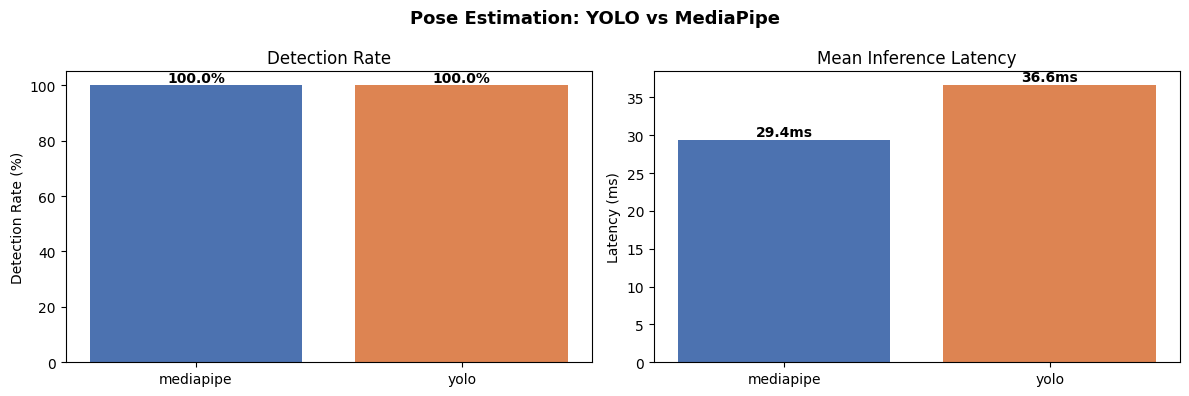

In [3]:
# Pose estimation benchmark summary
if df_bench is not None:
    pose_summary = df_bench.groupby("model").agg(
        detection_rate=("detected", "mean"),
        mean_latency_ms=("inference_ms", "mean"),
        median_latency_ms=("inference_ms", "median"),
        p95_latency_ms=("inference_ms", lambda x: np.percentile(x, 95)),
        total_frames=("detected", "count"),
    ).round(1)
    print("Pose Estimation Benchmark:")
    print(pose_summary.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    models = pose_summary.index.tolist()
    colors = ["#4C72B0", "#DD8452"]

    axes[0].bar(models, pose_summary["detection_rate"] * 100, color=colors)
    axes[0].set_ylabel("Detection Rate (%)")
    axes[0].set_title("Detection Rate")
    axes[0].set_ylim(0, 105)
    for i, v in enumerate(pose_summary["detection_rate"]):
        axes[0].text(i, v * 100 + 1, f"{v*100:.1f}%", ha="center", fontweight="bold")

    axes[1].bar(models, pose_summary["mean_latency_ms"], color=colors)
    axes[1].set_ylabel("Latency (ms)")
    axes[1].set_title("Mean Inference Latency")
    for i, v in enumerate(pose_summary["mean_latency_ms"]):
        axes[1].text(i, v + 0.5, f"{v:.1f}ms", ha="center", fontweight="bold")

    plt.suptitle("Pose Estimation: YOLO vs MediaPipe", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "08_pose_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Benchmark CSV not found — run notebook 03 first.")

## Section 3: Rep Counting Summary

State machine performance with tuned thresholds.

Rep Counting (State Machine, thresholds: 110°/145°):
  Total videos: 100
  Videos with ≥1 rep: 89 (89%)
  Total reps detected: 96
  Mean reps/video: 0.96
  Rep count range: 0–2


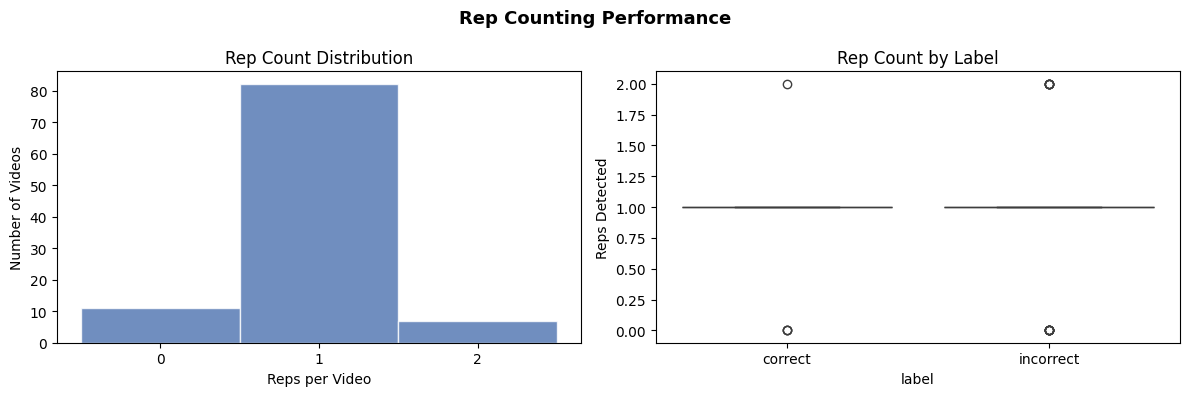

In [4]:
if df_counting is not None:
    total_reps = df_counting["rep_count"].sum()
    videos_with_reps = (df_counting["rep_count"] > 0).sum()
    total_videos = len(df_counting)

    print("Rep Counting (State Machine, thresholds: 110°/145°):")
    print(f"  Total videos: {total_videos}")
    print(f"  Videos with ≥1 rep: {videos_with_reps} ({100*videos_with_reps/total_videos:.0f}%)")
    print(f"  Total reps detected: {total_reps}")
    print(f"  Mean reps/video: {df_counting['rep_count'].mean():.2f}")
    print(f"  Rep count range: {df_counting['rep_count'].min()}–{df_counting['rep_count'].max()}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Rep count distribution
    axes[0].hist(df_counting["rep_count"], bins=range(0, df_counting["rep_count"].max() + 2),
                 edgecolor="white", color="#4C72B0", alpha=0.8, align="left")
    axes[0].set_xlabel("Reps per Video")
    axes[0].set_ylabel("Number of Videos")
    axes[0].set_title("Rep Count Distribution")
    axes[0].set_xticks(range(0, df_counting["rep_count"].max() + 1))

    # Rep count by label
    sns.boxplot(data=df_counting, x="label", y="rep_count", ax=axes[1],
                palette={"correct": "#2ca02c", "incorrect": "#d62728"},
                hue="label", legend=False)
    axes[1].set_title("Rep Count by Label")
    axes[1].set_ylabel("Reps Detected")

    plt.suptitle("Rep Counting Performance", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "08_counting_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Rep counting CSV not found — run notebook 05 first.")

## Section 4: Form Classification Comparison

Side-by-side comparison of all three classification approaches.

Form Classification: 5-Fold Stratified CV (per-rep, split by video)

       Method  Mean_Accuracy  Std_Accuracy
Baseline (LR)       0.823626      0.079662
       R3D-18       0.811930      0.065205
       ST-GCN       0.873567      0.071445


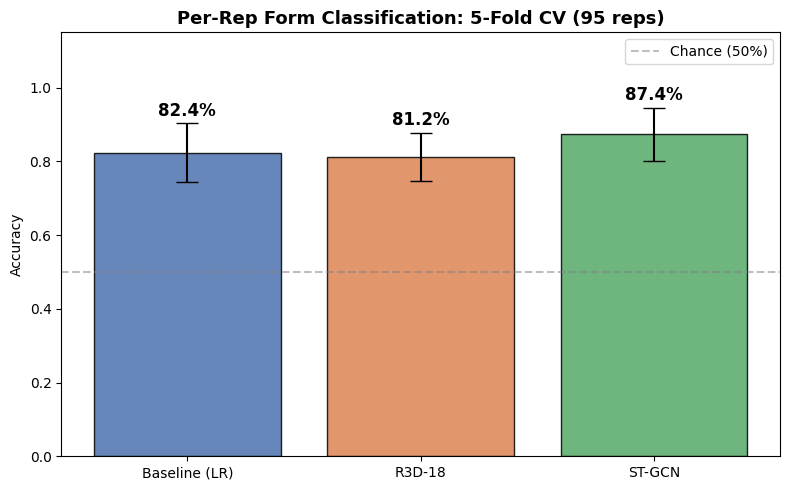



Model Comparison:
Model                Type                      Params       Input                     Accuracy  
--------------------------------------------------------------------------------------------
Baseline (LR)        Logistic Regression       16 features  Per-rep angle statistics  82.4% +/- 8.0%
R3D-18               3D CNN (frozen backbone)  1,026        16 video frames (112x112) 81.2% +/- 6.5%
ST-GCN               Graph Neural Network      244,290      Skeleton sequence (64 frames) 87.4% +/- 7.1%


In [5]:
if df_class_summary is not None:
    print("Form Classification: 5-Fold Stratified CV (per-rep, split by video)\n")
    print(df_class_summary[["Method", "Mean_Accuracy", "Std_Accuracy"]].to_string(index=False))

    methods = df_class_summary["Method"].tolist()
    means = df_class_summary["Mean_Accuracy"].tolist()
    stds = df_class_summary["Std_Accuracy"].tolist()

    # Main comparison bar chart
    colors = ["#4C72B0", "#DD8452", "#55A868"]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(methods, means, yerr=stds, capsize=8, color=colors, alpha=0.85, edgecolor="black")

    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.01,
                f"{mean:.1%}", ha="center", va="bottom", fontweight="bold", fontsize=12)

    ax.set_ylabel("Accuracy")
    ax.set_title("Per-Rep Form Classification: 5-Fold CV (95 reps)", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance (50%)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "08_classification_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Model comparison table
    print("\n\nModel Comparison:")
    print(f"{'Model':<20s} {'Type':<25s} {'Params':<12s} {'Input':<25s} {'Accuracy':<10s}")
    print("-" * 92)
    details = [
        ("Baseline (LR)", "Logistic Regression", "16 features", "Per-rep angle statistics"),
        ("R3D-18", "3D CNN (frozen backbone)", "1,026", "16 video frames (112x112)"),
        ("ST-GCN", "Graph Neural Network", "244,290", "Skeleton sequence (64 frames)"),
    ]
    for (model, mtype, params, inp), mean, std in zip(details, means, stds):
        print(f"{model:<20s} {mtype:<25s} {params:<12s} {inp:<25s} {mean:.1%} +/- {std:.1%}")
else:
    print("Classification summary not found — run notebook 06 first.")

## Section 5: Quality Scoring vs Classification

The quality scorer uses hand-crafted angle rules. How does it compare to the learned models?

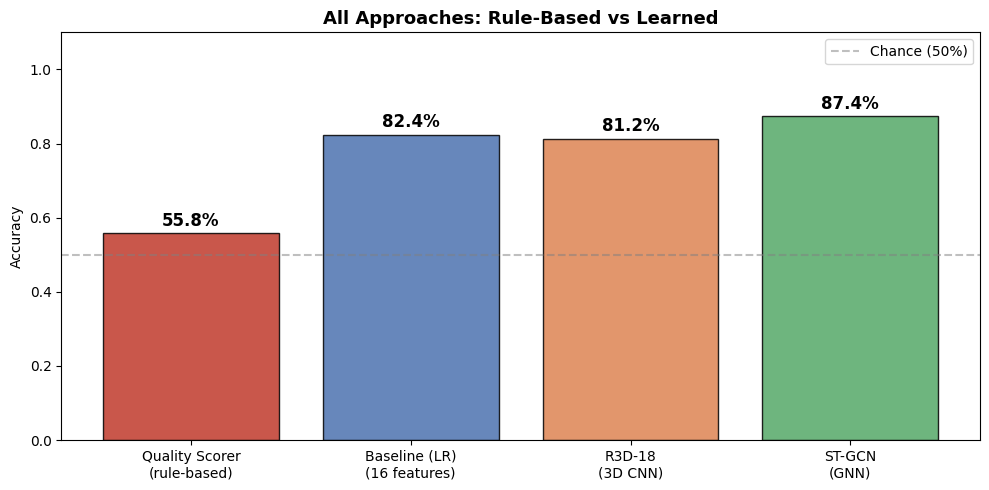

Summary: Rule-based scoring fails because correct and incorrect reps
have nearly identical angle profiles. The difference lies in temporal
movement patterns that only learned models (especially ST-GCN) capture.


In [6]:
if df_quality is not None:
    # Quality scorer as classifier: composite threshold
    y_true = (df_quality["label"] == "incorrect").astype(int)
    composite = df_quality["composite"].values

    from sklearn.metrics import accuracy_score, f1_score
    best_acc = 0
    best_th = 0
    for th in np.arange(10, 95, 1):
        preds = (composite < th).astype(int)
        acc = accuracy_score(y_true, preds)
        if acc > best_acc:
            best_acc = acc
            best_th = th

    # All approaches comparison
    all_methods = ["Quality Scorer\n(rule-based)", "Baseline (LR)\n(16 features)",
                   "R3D-18\n(3D CNN)", "ST-GCN\n(GNN)"]
    all_accs = [best_acc]
    all_colors = ["#C0392B"]

    if df_class_summary is not None:
        all_accs += df_class_summary["Mean_Accuracy"].tolist()
        all_colors += ["#4C72B0", "#DD8452", "#55A868"]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(all_methods, all_accs, color=all_colors, alpha=0.85, edgecolor="black")
    for bar, acc in zip(bars, all_accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{acc:.1%}", ha="center", va="bottom", fontweight="bold", fontsize=12)

    ax.set_ylabel("Accuracy")
    ax.set_title("All Approaches: Rule-Based vs Learned", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance (50%)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "08_all_approaches.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Summary: Rule-based scoring fails because correct and incorrect reps")
    print("have nearly identical angle profiles. The difference lies in temporal")
    print("movement patterns that only learned models (especially ST-GCN) capture.")
else:
    print("Quality scores not found — run notebook 07 first.")

## Section 6: End-to-End Demo on Sample Videos

Run the full pipeline on a few videos: pose estimation → rep counting → form classification → quality scoring.

In [7]:
from src.pose_estimation.yolo_estimator import YoloEstimator
from src.counting.state_machine import PushUpStateMachine
from src.features.angles import compute_angle_sequence
from src.quality.scoring import QualityScorer
from src.quality.feedback import generate_feedback
from src.classification.stgcn import PushUpSTGCN
from src.classification.form_checker import FormChecker

# Load manifest for sample videos
with open("../data/processed/keypoints/manifest.json") as f:
    manifest = json.load(f)

VIDEO_DIR = Path("../data/raw/kaggle_pushups")
KEYPOINT_DIR = Path("../data/processed/keypoints/yolo")
MODEL_PATH = Path("../models/stgcn_best.pt")

# Pick 3 correct + 3 incorrect videos that have reps
sample_vids = []
for label_name in ["correct", "incorrect"]:
    candidates = [v for v, info in manifest.items()
                  if info["label"] == label_name and v in df_counting["video_id"].values
                  and df_counting[df_counting["video_id"] == v]["rep_count"].values[0] > 0]
    sample_vids.extend(candidates[:3])

scorer = QualityScorer()

# Load ST-GCN if available
has_model = MODEL_PATH.exists()
if has_model:
    model = PushUpSTGCN(in_channels=2, num_classes=2)
    state_dict = torch.load(MODEL_PATH, map_location="cpu", weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()
    print(f"ST-GCN model loaded: {MODEL_PATH}")
else:
    print("ST-GCN model not found — skipping classification. Run notebook 06 first.")

print(f"\nRunning end-to-end pipeline on {len(sample_vids)} sample videos...\n")

for vid_id in sample_vids:
    kps = np.load(KEYPOINT_DIR / f"{vid_id}.npy")
    label = manifest[vid_id]["label"]

    # Rep counting
    sm = PushUpStateMachine(down_threshold=110.0, up_threshold=145.0)
    sm.label_sequence(kps)
    boundaries = sm.rep_boundaries

    print(f"{'='*60}")
    print(f"Video: {vid_id} (true: {label})")
    print(f"  Frames: {len(kps)} | Reps detected: {sm.count}")

    for bi, (start, end) in enumerate(boundaries):
        rep_kps = kps[start:end+1]

        # Quality scoring
        score = scorer.score_rep(rep_kps)
        feedback = generate_feedback(score)

        # Form classification (if model available)
        form_label = "—"
        if has_model:
            from src.features.normalize import torso_normalize
            norm_kps = torso_normalize(rep_kps)
            hip_mid = (norm_kps[:, 6, :2] + norm_kps[:, 7, :2]) / 2.0
            norm_kps[:, :, :2] -= hip_mid[:, np.newaxis, :]
            xy = norm_kps[:, :, :2]  # (T, 12, 2)

            T = len(xy)
            if T < 64:
                pad = np.zeros((64 - T, 12, 2), dtype=np.float32)
                xy = np.concatenate([xy, pad], axis=0)
            else:
                xy = xy[:64]

            tensor = torch.from_numpy(xy.astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
            with torch.no_grad():
                logits = model(tensor)
                probs = torch.softmax(logits, dim=-1).squeeze()
            form_label = "CORRECT" if probs[0] > probs[1] else "INCORRECT"
            form_conf = max(probs[0], probs[1]).item()
            form_label = f"{form_label} ({form_conf:.0%})"

        print(f"\n  Rep {bi+1} (frames {start}–{end}):")
        print(f"    Quality: back={score.back_alignment:.0f} depth={score.depth:.0f} "
              f"ext={score.extension:.0f} composite={score.composite:.0f}")
        print(f"    Classification: {form_label}")
        print(f"    Feedback: {feedback[0]}")

    print()

ST-GCN model loaded: ../models/stgcn_best.pt

Running end-to-end pipeline on 6 sample videos...

Video: correct__Copy_of_push_up_1 (true: correct)
  Frames: 61 | Reps detected: 1

  Rep 1 (frames 9–48):
    Quality: back=52 depth=84 ext=54 composite=64
    Classification: INCORRECT (100%)
    Feedback: Decent effort — focus on the areas below to improve.

Video: correct__Copy_of_push_up_100 (true: correct)
  Frames: 124 | Reps detected: 1

  Rep 1 (frames 59–94):
    Quality: back=86 depth=100 ext=51 composite=82
    Classification: INCORRECT (100%)
    Feedback: Good form overall with some room for improvement.

Video: correct__Copy_of_push_up_101 (true: correct)
  Frames: 77 | Reps detected: 1

  Rep 1 (frames 9–44):
    Quality: back=88 depth=100 ext=52 composite=83
    Classification: INCORRECT (100%)
    Feedback: Good form overall with some room for improvement.

Video: incorrect__1 (true: incorrect)
  Frames: 290 | Reps detected: 2

  Rep 1 (frames 36–106):
    Quality: back=75 

## Section 7: Key Findings & Summary Table

In [8]:
# Final summary table
print("=" * 70)
print("FINAL EVALUATION SUMMARY")
print("=" * 70)

print("\n1. DATASET")
print(f"   100 videos (50 correct, 50 incorrect)")
print(f"   95 reps segmented (thresholds: 110°/145°)")
print(f"   89% video coverage (11 videos with 0 detected reps)")

print("\n2. POSE ESTIMATION")
print(f"   Model: YOLO11s-pose")
print(f"   Format: Unified 12-joint skeleton (x, y, confidence)")
if df_bench is not None:
    yolo_stats = df_bench[df_bench["model"] == "yolo"] if "yolo" in df_bench["model"].values else df_bench
    print(f"   Detection rate: {yolo_stats['detected'].mean()*100:.1f}%")
    print(f"   Mean latency: {yolo_stats['inference_ms'].mean():.1f}ms/frame")

print("\n3. REP COUNTING")
print(f"   Method: Rule-based state machine (4-phase elbow angle FSM)")
print(f"   Thresholds: down=110°, up=145° (tuned in notebook 05)")
print(f"   Result: 95 reps from 89 videos")

print("\n4. FORM CLASSIFICATION (per-rep, 5-fold CV)")
print(f"   {'Model':<25s} {'Accuracy':<15s} {'Type'}")
print(f"   {'-'*65}")
if df_class_summary is not None:
    for _, row in df_class_summary.iterrows():
        types = {"Baseline (LR)": "Logistic Regression",
                 "R3D-18": "3D CNN (frozen backbone)",
                 "ST-GCN": "Graph Neural Network"}
        t = types.get(row["Method"], "")
        print(f"   {row['Method']:<25s} {row['Mean_Accuracy']:.1%} +/- {row['Std_Accuracy']:.1%}   {t}")

print("\n5. QUALITY SCORING (rule-based)")
print(f"   Criteria: back alignment (40%), depth (35%), extension (25%)")
print(f"   As classifier: 49.5% accuracy (worse than random)")
print(f"   Conclusion: cannot separate correct from incorrect form")

print("\n6. KEY FINDINGS")
print(f"   • ST-GCN (GNN on skeleton data) outperforms 3D CNN on raw video")
print(f"   • Simple angle features (LR baseline) match the 3D CNN")
print(f"   • Rule-based quality scoring fails — form differences are temporal,")
print(f"     not captured by static angle thresholds")
print(f"   • Per-rep classification enables real-time form feedback in live demo")
print(f"   • Graph structure explicitly modeling joint relationships adds value")
print("=" * 70)

FINAL EVALUATION SUMMARY

1. DATASET
   100 videos (50 correct, 50 incorrect)
   95 reps segmented (thresholds: 110°/145°)
   89% video coverage (11 videos with 0 detected reps)

2. POSE ESTIMATION
   Model: YOLO11s-pose
   Format: Unified 12-joint skeleton (x, y, confidence)
   Detection rate: 100.0%
   Mean latency: 36.6ms/frame

3. REP COUNTING
   Method: Rule-based state machine (4-phase elbow angle FSM)
   Thresholds: down=110°, up=145° (tuned in notebook 05)
   Result: 95 reps from 89 videos

4. FORM CLASSIFICATION (per-rep, 5-fold CV)
   Model                     Accuracy        Type
   -----------------------------------------------------------------
   Baseline (LR)             82.4% +/- 8.0%   Logistic Regression
   R3D-18                    81.2% +/- 6.5%   3D CNN (frozen backbone)
   ST-GCN                    87.4% +/- 7.1%   Graph Neural Network

5. QUALITY SCORING (rule-based)
   Criteria: back alignment (40%), depth (35%), extension (25%)
   As classifier: 49.5% accuracy

## Section 8: Save Final Figures

In [ ]:
# List all saved figures
print("Figures saved during this evaluation:")
for f in sorted(FIGURES_DIR.glob("08_*.png")):
    print(f"  {f.name}")

print(f"\nAll figures directory: {FIGURES_DIR}")
print(f"All results directory: {RESULTS_DIR}")

# List all result CSVs
print("\nResult files:")
for f in sorted(RESULTS_DIR.glob("*.csv")):
    print(f"  {f.name}")